In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
from pathlib import Path

from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets
from ewatercycle.forcing import sources

project_dir = Path("/home/niels/BEP-Niels")
temp_dir = project_dir / "temp_runs"
results_dir = project_dir / "results"
figures_dir = project_dir / "Results-figures"

temp_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

print("Project:", project_dir)
print("Results:", results_dir)

Project: /home/niels/BEP-Niels
Results: /home/niels/BEP-Niels/results


In [18]:
model_start = "1986-01-01T00:00:00Z"   # warm-up
model_end = "2019-12-31T00:00:00Z"     # exclusief, dus t/m 2019-12-31

output_start = "1987-01-01"
output_end = "2019-12-31"

shape_file = project_dir / "Rhine" / "Rhine.shp"
dem_file = Path("/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/wflow_dem.map")
forcing_directory = temp_dir / "forcing_ERA5_Rhine_1986_2019"

print("Shape bestaat:", shape_file.exists())
print("DEM bestaat:", dem_file.exists())
print("Forcing directory:", forcing_directory)

Shape bestaat: True
DEM bestaat: True
Forcing directory: /home/niels/BEP-Niels/temp_runs/forcing_ERA5_Rhine_1986_2019


In [19]:
grdc = df[
    (df["date"] >= output_start) &
    (df["date"] <= output_end)
][["date", "Q_m3s"]].copy()

grdc = grdc.rename(columns={"Q_m3s": "Q_grdc_m3s"})

print("GRDC start:", grdc["date"].min())
print("GRDC einde:", grdc["date"].max())
print("Aantal dagen:", len(grdc))

GRDC start: 1987-01-01 00:00:00
GRDC einde: 2019-12-31 00:00:00
Aantal dagen: 12053


In [20]:
parameter_sets = available_parameter_sets(target_model="wflow")
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]
parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

lat_lobith_model = 51.849999998
lon_lobith_model = 6.0999999998

print("Config bestaat:", parameter_set.config.exists())
print("Lobith:", lat_lobith_model, lon_lobith_model)

Config bestaat: True
Lobith: 51.849999998 6.0999999998


In [21]:
print("model_start:", model_start)
print("model_end:", model_end)
print("output_start:", output_start)
print("output_end:", output_end)
print("forcing_directory:", forcing_directory)

if forcing_directory.exists():
    nc_files = sorted(forcing_directory.rglob("wflow_ERA5_Rhine_*.nc"))
    
    if len(nc_files) == 0:
        print("Incomplete forcingmap gevonden, wordt verwijderd:")
        print(forcing_directory)
        shutil.rmtree(forcing_directory)
    else:
        print("Bestaande bruikbare forcing gevonden:")
        for file in nc_files:
            print(file)

model_start: 1986-01-01T00:00:00Z
model_end: 2019-12-31T00:00:00Z
output_start: 1987-01-01
output_end: 2019-12-31
forcing_directory: /home/niels/BEP-Niels/temp_runs/forcing_ERA5_Rhine_1986_2019
Incomplete forcingmap gevonden, wordt verwijderd:
/home/niels/BEP-Niels/temp_runs/forcing_ERA5_Rhine_1986_2019


In [22]:
WflowForcing = sources["WflowForcing"]

nc_files = []

if forcing_directory.exists():
    nc_files = sorted(forcing_directory.rglob("wflow_ERA5_Rhine_*.nc"))

    if len(nc_files) > 0:
        print("Bestaande forcing gevonden, geen nieuwe forcing gemaakt.")

if not forcing_directory.exists():
    print("Nieuwe forcing wordt gemaakt.")

    forcing_generated = WflowForcing.generate(
        dataset="ERA5",
        start_time=model_start,
        end_time=model_end,
        shape=str(shape_file),
        dem_file=str(dem_file),
        directory=str(forcing_directory),
    )

    print("Forcing aangemaakt:", forcing_generated.directory)

nc_files = sorted(forcing_directory.rglob("wflow_ERA5_Rhine_*.nc"))

print("Aantal forcing nc-bestanden:", len(nc_files))
for file in nc_files:
    print(file)

forcing_file = nc_files[0]
forcing_dir = forcing_file.parent

forcing = WflowForcing(
    start_time=model_start,
    end_time=model_end,
    directory=str(forcing_dir),
    shape=str(shape_file),
    netcdfinput=forcing_file.name,
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print("Gekozen forcing:", forcing_file)

Nieuwe forcing wordt gemaakt.
Forcing aangemaakt: /home/niels/BEP-Niels/temp_runs/forcing_ERA5_Rhine_1986_2019/work/diagnostic/script
Aantal forcing nc-bestanden: 1
/home/niels/BEP-Niels/temp_runs/forcing_ERA5_Rhine_1986_2019/work/diagnostic/script/wflow_ERA5_Rhine_1986_2019.nc
Gekozen forcing: /home/niels/BEP-Niels/temp_runs/forcing_ERA5_Rhine_1986_2019/work/diagnostic/script/wflow_ERA5_Rhine_1986_2019.nc


In [23]:
import xarray as xr

ds = xr.open_dataset(forcing_file)

print("Start forcing:", ds["time"].values[0])
print("Einde forcing:", ds["time"].values[-1])
print("Variabelen:", list(ds.data_vars))

ds.close()

Start forcing: 1986-01-01T12:00:00.000000000
Einde forcing: 2019-12-31T12:00:00.000000000
Variabelen: ['pr', 'time_bnds', 'lat_bnds', 'lon_bnds', 'tas', 'pet']


In [24]:
output_start = "1987-01-01"
output_end = "2019-12-30"   # veilig, omdat model_end op 2019-12-31 staat

grdc = df[
    (df["date"] >= output_start) &
    (df["date"] <= output_end)
][["date", "Q_m3s"]].copy()

grdc = grdc.rename(columns={"Q_m3s": "Q_grdc_m3s"})

print("GRDC start:", grdc["date"].min())
print("GRDC einde:", grdc["date"].max())
print("Aantal dagen:", len(grdc))

GRDC start: 1987-01-01 00:00:00
GRDC einde: 2019-12-30 00:00:00
Aantal dagen: 12052


In [26]:
def multiply_tbl_last_column(tbl_file, factor):
    tbl_file = Path(tbl_file)
    text = tbl_file.read_text()
    
    new_lines = []

    for line in text.splitlines():
        stripped = line.strip()

        if stripped == "" or stripped.startswith("#"):
            new_lines.append(line)
            continue

        parts = line.split()

        try:
            old_value = float(parts[-1])
            new_value = old_value * factor
            parts[-1] = str(new_value)
            new_lines.append(" ".join(parts))
        except:
            new_lines.append(line)

    tbl_file.write_text("\n".join(new_lines) + "\n")


def apply_parameter_factors(cfg_dir, factors):
    cfg_dir = Path(cfg_dir)

    for tbl_name, factor in factors.items():
        files = list(cfg_dir.rglob(tbl_name))

        if len(files) == 0:
            print("Niet gevonden:", tbl_name)
            continue

        for file in files:
            print("Aanpassen:", file.relative_to(cfg_dir), "factor:", factor)
            multiply_tbl_last_column(file, factor)


def run_wflow(run_name, factors):
    cfg_dir_run = temp_dir / f"run_{run_name}"

    if cfg_dir_run.exists():
        print("Oude runmap verwijderen:", cfg_dir_run)
        shutil.rmtree(cfg_dir_run)

    model = Wflow(
        parameter_set=parameter_set,
        forcing=forcing
    )

    cfg_file, cfg_dir = model.setup(cfg_dir=str(cfg_dir_run))
    cfg_dir = Path(cfg_dir)

    # Parameters aanpassen vóór initialize
    apply_parameter_factors(cfg_dir, factors)

    model.initialize(cfg_file)

    q_values = []
    times = []

    i = 0

    while model.time < model.end_time:
        model.update()

        q_lobith = model.get_value_at_coords(
            "RiverRunoff",
            lat=[float(lat_lobith_model)],
            lon=[float(lon_lobith_model)]
        )[0]

        q_values.append(float(q_lobith))
        times.append(model.time_as_datetime)

        i += 1

        if i % 365 == 0:
            print(
                "Stap:", i,
                "Tijd:", model.time_as_datetime,
                "Q:", round(float(q_lobith), 1)
            )

    model.finalize()

    output = pd.DataFrame({
        "date": pd.to_datetime(times, utc=True),
        "Q_model_m3s": q_values
    })

    output["date"] = output["date"].dt.tz_convert(None).dt.floor("D")

    output = output[
        (output["date"] >= output_start) &
        (output["date"] <= output_end)
    ].copy()

    out_file = results_dir / f"{run_name}_lobith_daily.csv"
    output.to_csv(out_file, index=False)

    print("Run klaar:", run_name)
    print("Opgeslagen als:", out_file)

    return output

In [27]:
run_name = "calibrated_3_1987_2019"
run_file = results_dir / f"{run_name}_lobith_daily.csv"

factors_calibrated_3 = {
    "EoverR.tbl": 0.75,
    "RootingDepth.tbl": 0.90,
    "N_River.tbl": 4.0
}

if run_file.exists():
    print("Bestaande output gevonden:")
    print(run_file)
    
    model_cal3 = pd.read_csv(run_file)
    model_cal3["date"] = pd.to_datetime(model_cal3["date"])
    
else:
    print("Geen bestaande output gevonden. calibrated_3 wordt nu gedraaid.")
    
    model_cal3 = run_wflow(
        run_name=run_name,
        factors=factors_calibrated_3
    )

model_cal3 = model_cal3.rename(columns={"Q_model_m3s": "Q_calibrated_3_m3s"})

print("Modeloutput start:", model_cal3["date"].min())
print("Modeloutput einde:", model_cal3["date"].max())
print("Aantal dagen:", len(model_cal3))

model_cal3.head()

Geen bestaande output gevonden. calibrated_3 wordt nu gedraaid.


Aanpassen: intbl/EoverR.tbl factor: 0.75
Aanpassen: intbl/RootingDepth.tbl factor: 0.9
Aanpassen: intbl/N_River.tbl factor: 4.0
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 7962.2
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 3375.2
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 6642.7
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 5663.7
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 4775.6
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 3900.9
Stap: 2555 Tijd: 1992-12-29 00:00:00 Q: 4201.8
Stap: 2920 Tijd: 1993-12-29 00:00:00 Q: 16131.0
Stap: 3285 Tijd: 1994-12-29 00:00:00 Q: 3402.9
Stap: 3650 Tijd: 1995-12-29 00:00:00 Q: 2447.6
Stap: 4015 Tijd: 1996-12-28 00:00:00 Q: 3288.2
Stap: 4380 Tijd: 1997-12-28 00:00:00 Q: 7724.8
Stap: 4745 Tijd: 1998-12-28 00:00:00 Q: 3991.4
Stap: 5110 Tijd: 1999-12-28 00:00:00 Q: 9221.1
Stap: 5475 Tijd: 2000-12-27 00:00:00 Q: 3815.2
Stap: 5840 Tijd: 2001-12-27 00:00:00 Q: 3136.3
Stap: 6205 Tijd: 2002-12-27 00:00:00 Q: 3262.4
Stap: 6570 Tijd: 2003-12-27 00:00:00 Q: 2147.8
Stap: 6935 Tijd: 2004-12-26

,date,Q_calibrated_3_m3s
365,1987-01-01,9125.787109
366,1987-01-02,10393.553711
367,1987-01-03,11656.896484
368,1987-01-04,12782.655273
369,1987-01-05,13590.301758


In [28]:
run_file = results_dir / "calibrated_3_1987_2019_lobith_daily.csv"

model_cal3 = pd.read_csv(run_file)
model_cal3["date"] = pd.to_datetime(model_cal3["date"])

if "Q_model_m3s" in model_cal3.columns:
    model_cal3 = model_cal3.rename(columns={"Q_model_m3s": "Q_calibrated_3_m3s"})

print("Model start:", model_cal3["date"].min())
print("Model einde:", model_cal3["date"].max())
print("Aantal modeldagen:", len(model_cal3))

model_cal3.head()

Model start: 1987-01-01 00:00:00
Model einde: 2019-12-30 00:00:00
Aantal modeldagen: 12052


,date,Q_calibrated_3_m3s
0,1987-01-01,9125.787109
1,1987-01-02,10393.553711
2,1987-01-03,11656.896484
3,1987-01-04,12782.655273
4,1987-01-05,13590.301758


In [29]:
# GRDC-data selecteren voor dezelfde periode

grdc_long = df[
    (df["date"] >= model_cal3["date"].min()) &
    (df["date"] <= model_cal3["date"].max())
][["date", "Q_m3s"]].copy()

grdc_long = grdc_long.rename(columns={"Q_m3s": "Q_grdc_m3s"})

comparison_long = pd.merge(
    grdc_long,
    model_cal3[["date", "Q_calibrated_3_m3s"]],
    on="date",
    how="inner"
)

print("Start comparison:", comparison_long["date"].min())
print("Einde comparison:", comparison_long["date"].max())
print("Aantal dagen:", len(comparison_long))

comparison_long.head()

Start comparison: 1987-01-01 00:00:00
Einde comparison: 2019-12-30 00:00:00
Aantal dagen: 12052


,date,Q_grdc_m3s,Q_calibrated_3_m3s
0,1987-01-01,4865.0,9125.787109
1,1987-01-02,5756.0,10393.553711
2,1987-01-03,6160.0,11656.896484
3,1987-01-04,6973.0,12782.655273
4,1987-01-05,7579.0,13590.301758


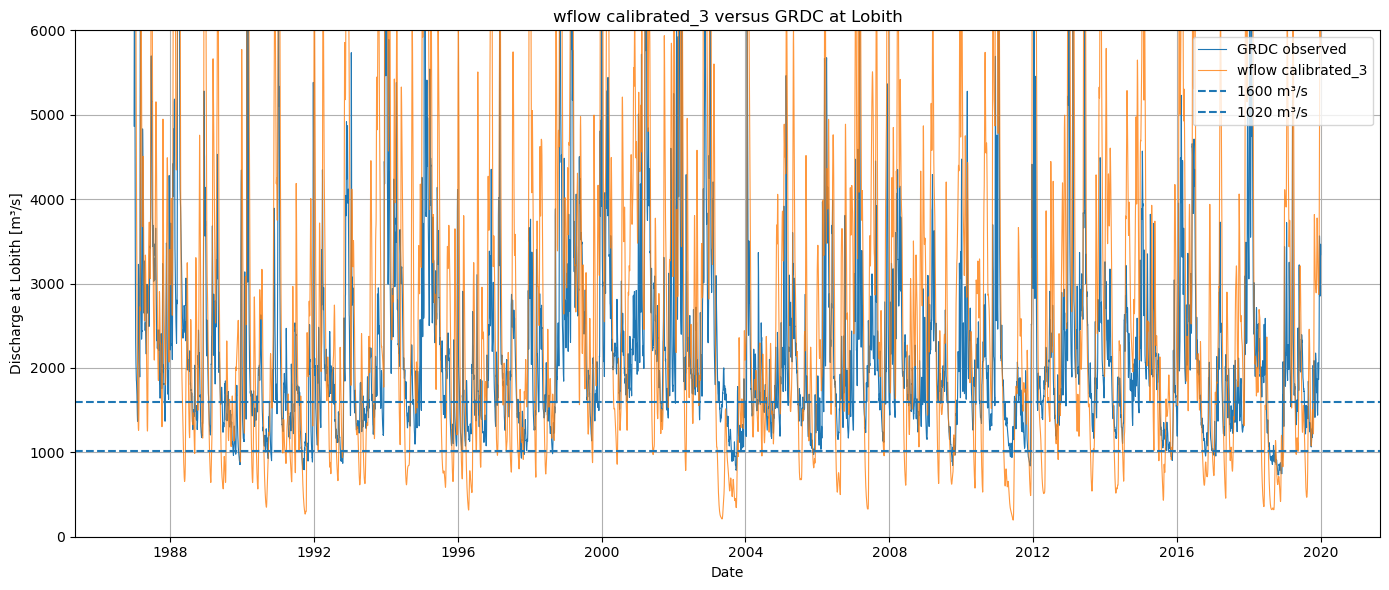

In [30]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_long["date"],
    comparison_long["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=0.8
)

plt.plot(
    comparison_long["date"],
    comparison_long["Q_calibrated_3_m3s"],
    label="wflow calibrated_3",
    linewidth=0.8,
    alpha=0.8
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 6000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("wflow calibrated_3 versus GRDC at Lobith")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
def calculate_scores(data, obs_col, sim_col):
    d = data[[obs_col, sim_col]].dropna().copy()

    obs = d[obs_col].astype(float)
    sim = d[sim_col].astype(float)

    bias = (sim - obs).mean()
    rmse = np.sqrt(((sim - obs) ** 2).mean())

    eps = 1.0
    log_obs = np.log(obs.clip(lower=eps))
    log_sim = np.log(sim.clip(lower=eps))

    log_nse = 1 - ((log_sim - log_obs) ** 2).sum() / ((log_obs - log_obs.mean()) ** 2).sum()

    return {
        "bias_m3s": round(bias, 1),
        "rmse_m3s": round(rmse, 1),
        "log_nse": round(log_nse, 3),
        "n_days": len(d)
    }


def make_score_table(data, model_columns, obs_col="Q_grdc_m3s"):
    rows = []

    for run_name, sim_col in model_columns.items():
        scores = calculate_scores(data, obs_col, sim_col)
        scores["run"] = run_name
        rows.append(scores)

    table = pd.DataFrame(rows)
    table = table[["run", "bias_m3s", "rmse_m3s", "log_nse", "n_days"]]

    return table

In [32]:
def fit_quantile_mapping(obs_train, sim_train, n_quantiles=101):
    obs_train = np.array(obs_train)
    sim_train = np.array(sim_train)

    qs = np.linspace(0, 1, n_quantiles)

    sim_q = np.quantile(sim_train, qs)
    obs_q = np.quantile(obs_train, qs)

    # Dubbele simulatiewaarden verwijderen
    sim_q_unique, unique_index = np.unique(sim_q, return_index=True)
    obs_q_unique = obs_q[unique_index]

    return sim_q_unique, obs_q_unique


def apply_quantile_mapping(sim_values, sim_q, obs_q):
    sim_values = np.array(sim_values)

    corrected = np.interp(
        sim_values,
        sim_q,
        obs_q,
        left=obs_q[0],
        right=obs_q[-1]
    )

    return corrected

In [33]:
cal_start = "1987-01-01"
cal_end = "2000-12-31"

val_start = "2001-01-01"
val_end = "2019-12-30"

calibration_data = comparison_long[
    (comparison_long["date"] >= cal_start) &
    (comparison_long["date"] <= cal_end)
].copy()

validation_data = comparison_long[
    (comparison_long["date"] >= val_start) &
    (comparison_long["date"] <= val_end)
].copy()

print("Kalibratieperiode:")
print(calibration_data["date"].min(), "t/m", calibration_data["date"].max())
print("Aantal dagen:", len(calibration_data))

print("\nValidatieperiode:")
print(validation_data["date"].min(), "t/m", validation_data["date"].max())
print("Aantal dagen:", len(validation_data))

Kalibratieperiode:
1987-01-01 00:00:00 t/m 2000-12-31 00:00:00
Aantal dagen: 5114

Validatieperiode:
2001-01-01 00:00:00 t/m 2019-12-30 00:00:00
Aantal dagen: 6938


In [34]:
sim_q_cal, obs_q_cal = fit_quantile_mapping(
    obs_train=calibration_data["Q_grdc_m3s"],
    sim_train=calibration_data["Q_calibrated_3_m3s"],
    n_quantiles=101
)

print("Bias-correctie gefit op 1987-2000")

Bias-correctie gefit op 1987-2000


In [35]:
comparison_bc = comparison_long.copy()

comparison_bc["Q_calibrated_3_bc_m3s"] = apply_quantile_mapping(
    sim_values=comparison_bc["Q_calibrated_3_m3s"],
    sim_q=sim_q_cal,
    obs_q=obs_q_cal
)

comparison_bc.head()

,date,Q_grdc_m3s,Q_calibrated_3_m3s,Q_calibrated_3_bc_m3s
0,1987-01-01,4865.0,9125.787109,5505.928477
1,1987-01-02,5756.0,10393.553711,6326.978960
2,1987-01-03,6160.0,11656.896484,7073.809847
3,1987-01-04,6973.0,12782.655273,7908.372864
4,1987-01-05,7579.0,13590.301758,8513.539789


In [36]:
calibration_bc = comparison_bc[
    (comparison_bc["date"] >= cal_start) &
    (comparison_bc["date"] <= cal_end)
].copy()

model_columns = {
    "calibrated_3_raw": "Q_calibrated_3_m3s",
    "calibrated_3_bc": "Q_calibrated_3_bc_m3s"
}

score_cal_all = make_score_table(
    calibration_bc,
    model_columns
)

score_cal_low = make_score_table(
    calibration_bc[calibration_bc["Q_grdc_m3s"] < 1600],
    model_columns
)

print("Scores kalibratieperiode, alle dagen:")
display(score_cal_all)

print("Scores kalibratieperiode, GRDC < 1600:")
display(score_cal_low)

Scores kalibratieperiode, alle dagen:


,run,bias_m3s,rmse_m3s,log_nse,n_days
0,calibrated_3_raw,787.5,1726.7,-0.506,5114
1,calibrated_3_bc,-0.1,753.1,0.485,5114


Scores kalibratieperiode, GRDC < 1600:


,run,bias_m3s,rmse_m3s,log_nse,n_days
0,calibrated_3_raw,285.8,823.2,-11.547,1697
1,calibrated_3_bc,233.9,453.1,-3.008,1697


In [37]:
validation_bc = comparison_bc[
    (comparison_bc["date"] >= val_start) &
    (comparison_bc["date"] <= val_end)
].copy()

score_val_all = make_score_table(
    validation_bc,
    model_columns
)

score_val_low = make_score_table(
    validation_bc[validation_bc["Q_grdc_m3s"] < 1600],
    model_columns
)

print("Scores validatieperiode, alle dagen:")
display(score_val_all)

print("Scores validatieperiode, GRDC < 1600:")
display(score_val_low)

Scores validatieperiode, alle dagen:


,run,bias_m3s,rmse_m3s,log_nse,n_days
0,calibrated_3_raw,692.7,1586.7,-0.880,6938
1,calibrated_3_bc,5.2,706.7,0.454,6938


Scores validatieperiode, GRDC < 1600:


,run,bias_m3s,rmse_m3s,log_nse,n_days
0,calibrated_3_raw,173.7,784.4,-9.534,2267
1,calibrated_3_bc,183.4,409.9,-1.402,2267


In [38]:
threshold_table = []

for run_name, q_col in model_columns.items():
    threshold_table.append({
        "run": run_name,
        "days_below_1600": (validation_bc[q_col] < 1600).sum(),
        "days_below_1020": (validation_bc[q_col] < 1020).sum()
    })

threshold_table = pd.DataFrame(threshold_table)

print("GRDC validatie dagen < 1600:", (validation_bc["Q_grdc_m3s"] < 1600).sum())
print("GRDC validatie dagen < 1020:", (validation_bc["Q_grdc_m3s"] < 1020).sum())

display(threshold_table)

GRDC validatie dagen < 1600: 2267
GRDC validatie dagen < 1020: 315


,run,days_below_1600,days_below_1020
0,calibrated_3_raw,2281,1142
1,calibrated_3_bc,2418,510


In [39]:
q_cols = {
    "GRDC": "Q_grdc_m3s",
    "calibrated_3_raw": "Q_calibrated_3_m3s",
    "calibrated_3_bc": "Q_calibrated_3_bc_m3s"
}

rows = []

for name, col in q_cols.items():
    rows.append({
        "run": name,
        "Q5": validation_bc[col].quantile(0.05),
        "Q10": validation_bc[col].quantile(0.10),
        "Q20": validation_bc[col].quantile(0.20),
        "median": validation_bc[col].quantile(0.50),
        "mean": validation_bc[col].mean()
    })

quantile_table_val = pd.DataFrame(rows).round(1)
quantile_table_val

,run,Q5,Q10,Q20,median,mean
0,GRDC,1033.0,1179.0,1374.0,1879.0,2137.5
1,calibrated_3_raw,555.3,725.9,1158.8,2259.6,2830.1
2,calibrated_3_bc,966.1,1109.1,1333.0,1886.4,2142.7


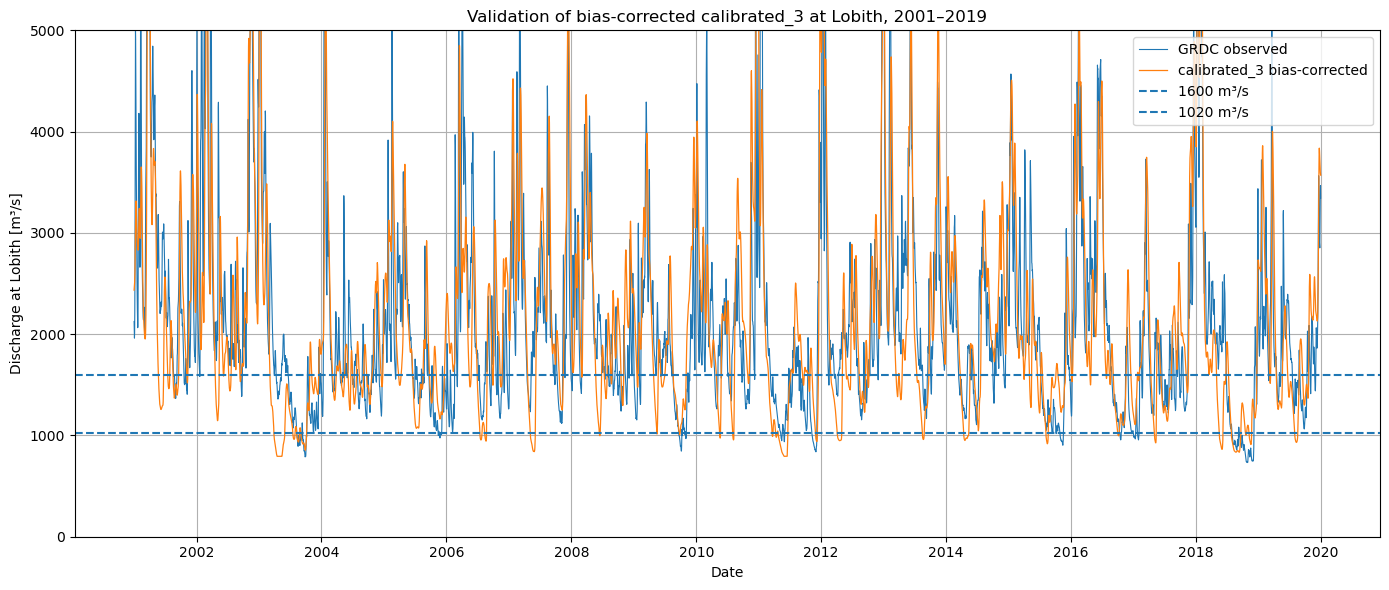

In [41]:
plt.figure(figsize=(14, 6))

plt.plot(
    validation_bc["date"],
    validation_bc["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=0.8
)

# plt.plot(
#     validation_bc["date"],
#     validation_bc["Q_calibrated_3_m3s"],
#     label="calibrated_3 raw",
#     linewidth=0.7,
#     alpha=0.7
# )

plt.plot(
    validation_bc["date"],
    validation_bc["Q_calibrated_3_bc_m3s"],
    label="calibrated_3 bias-corrected",
    linewidth=0.9
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 5000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Validation of bias-corrected calibrated_3 at Lobith, 2001–2019")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
output_file = results_dir / "calibrated_3_bias_corrected_1987_2019_lobith.csv"

comparison_bc.to_csv(output_file, index=False)

print("Opgeslagen als:")
print(output_file)